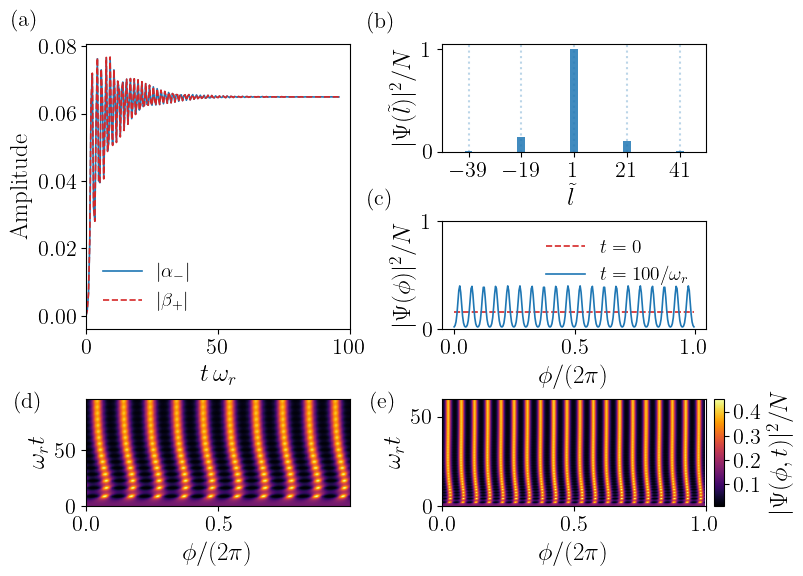

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator
import os

# ==================================================
# LOAD DATA
# ==================================================

# -------- PART 1 → (a), (b), (c)
d1 = np.load(os.path.join(data_dir, "Figure_3_data_1.npz"))

t_scaled = d1["t_scaled"]
a_minus  = d1["a_minus"]
b_plus   = d1["b_plus"]

l_vals = d1["l_vals"]
psi_k_density = d1["psi_k_density"]

phi = d1["phi"]
psi_init = d1["psi_init"]
psi_final = d1["psi_final"]

# -------- PART 2 → (d)
d2 = np.load(os.path.join(data_dir, "Figure_3_data_2.npz"))

phi_d = d2["phi_d"]
time_d = d2["time_d"]
density1 = d2["density"]

# -------- PART 3 → (e)
d3 = np.load(os.path.join(data_dir, "Figure_3_data_3.npz"))

phi_e = d3["phi_e"]
time_e = d3["time_e"]
density2 = d3["density"]

# ==================================================
# SHAPE SAFETY (important for pcolormesh)
# ==================================================
if density1.shape != (len(time_d), len(phi_d)):
    density1 = density1.T

if density2.shape != (len(time_e), len(phi_e)):
    density2 = density2.T

# ==================================================
# PRA STYLE
# ==================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
})

fig = plt.figure(figsize=(8, 6))

# ==================================================
# LAYOUT
# ==================================================
gs = GridSpec(3, 2, figure=fig, hspace=0.65, wspace=0.35)

ax_a = fig.add_subplot(gs[0:2, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 1])
ax_e = fig.add_subplot(gs[2, 0])
ax_f = fig.add_subplot(gs[2, 1])

def add_panel_label(ax, label, x=-0.27, y=0.8):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=16, va='top', ha='left')

# ==================================================
# (a)
# ==================================================
ax_a.plot(t_scaled, np.abs(a_minus), lw=1.2, label=r'$|\alpha_-|$')
ax_a.plot(t_scaled, np.abs(b_plus), lw=1.2, ls='--',
          color='tab:red', label=r'$|\beta_+|$')

ax_a.set_xlabel(r'$t\,\omega_r$')
ax_a.set_ylabel(r'Amplitude')
ax_a.set_xlim([0, 100])
ax_a.legend(frameon=False)
add_panel_label(ax_a, '(a)', x=-0.28, y=1.12)

# ==================================================
# (b)
# ==================================================
Lp, ell = 1, 10
orders = [-2, -1, 0, 1, 2]
tick_vals = [Lp + 2*m*ell for m in orders]

ax_b.bar(l_vals, psi_k_density, width=3.0, alpha=0.85)

ax_b.set_xlabel(r'$\tilde{l}$')
ax_b.set_ylabel(r'$|\Psi(\tilde{l})|^2/N$')
ax_b.set_xlim(tick_vals[0]-ell, tick_vals[-1]+ell)
ax_b.set_xticks(tick_vals)

for v in tick_vals:
    ax_b.axvline(v, ls=':', alpha=0.3)

add_panel_label(ax_b, '(b)', x=-0.28, y=1.3)

# ==================================================
# (c)
# ==================================================
ax_c.plot(phi/(2*np.pi), np.abs(psi_init)**2,
          lw=1.2, ls='--', color='tab:red', label=r'$t=0$')
ax_c.plot(phi/(2*np.pi), np.abs(psi_final)**2,
          lw=1.2, label=r'$t=100/\omega_r$')

ax_c.set_xlabel(r'$\phi/(2\pi)$')
ax_c.set_ylabel(r'$|\Psi(\phi)|^2/N$')
ax_c.set_ylim(0, 1)
ax_c.set_yticks([0, 1])
ax_c.legend(frameon=False)
add_panel_label(ax_c, '(c)', x=-0.28, y=1.3)

# ==================================================
# FIX SHAPE (SAFE)
# ==================================================
if density1.shape != (len(time_d), len(phi_d)):
    density1 = density1.T

if density2.shape != (len(time_e), len(phi_e)):
    density2 = density2.T

# ==================================================
# (d)
# ==================================================
im0 = ax_e.pcolormesh(
    phi_d,
    time_d,
    density1,
    cmap='inferno',
    shading='nearest'  
)
ax_e.set_ylabel(r'$\omega_r t$')
ax_e.set_xlabel(r'$\phi/(2\pi)$')
add_panel_label(ax_e, '(d)', x=-0.27, y=1.06)
# ==================================================
# (e)
# ==================================================
im1 = ax_f.pcolormesh(
    phi_e,
    time_e,
    density2,
    cmap='inferno',
    shading='nearest' 
)

ax_f.set_xlabel(r'$\phi/(2\pi)$')
ax_f.set_ylabel(r'$\omega_r t$')
ax_f.set_xlim(0, 1)
ax_f.set_ylim(0, 60)
add_panel_label(ax_f, '(e)', x=-0.27, y=1.06)

# ==================================================
# COLORBAR
# ==================================================
pos_f = ax_f.get_position()

cax = fig.add_axes([
    pos_f.x1 + 0.01,
    pos_f.y0,
    0.012,
    pos_f.height
])

cbar = fig.colorbar(im1, cax=cax)
cbar.set_label(r'$|\Psi(\phi,t)|^2/N$')
cbar.locator = MaxNLocator(nbins=5)
cbar.update_ticks()

# ==================================================
# BOX STYLE
# ==================================================
for ax in [ax_a, ax_b, ax_c, ax_e, ax_f]:
    for spine in ax.spines.values():
        spine.set_visible(True)

plt.show()